In [1]:
# nSTAT-python notebook example: mEPSCAnalysis
from pathlib import Path
import sys

REPO_ROOT = Path.cwd().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
SRC_PATH = (REPO_ROOT / "src").resolve()
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
from scipy.io import loadmat

from nstat import Analysis, Covariate, FitResSummary, Trial, TrialConfig, nspikeTrain, nstColl
from nstat.ConfigColl import ConfigColl
from nstat.CovColl import CovColl
from nstat.Events import Events
from nstat.data_manager import ensure_example_data
from nstat.notebook_figures import FigureTracker

np.random.seed(0)
DATA_DIR = ensure_example_data(download=True)
OUTPUT_ROOT = REPO_ROOT / "output" / "notebook_images"
__tracker = FigureTracker(topic='mEPSCAnalysis', output_root=OUTPUT_ROOT, expected_count=4)

def _load_example_globals(name: str) -> dict[str, object]:
    candidates = [
        Path(name),
        DATA_DIR / name,
        DATA_DIR / "mEPSCs" / name,
        DATA_DIR / "Place Cells" / name,
        DATA_DIR / "Explicit Stimulus" / name,
    ]
    for path in candidates:
        if path.exists():
            data = loadmat(path)
            return {k: v for k, v in data.items() if not k.startswith("__")}
    return {}

# SECTION 0: Section 0
# MINIATURE EXCITATORY POST-SYNAPTIC CURRENTS (mEPSCs)
# Data from Marnie Phillips; this notebook keeps the original analysis narrative but replaces the old placeholder cells with executable Python workflows.

In [2]:
# SECTION 1: Data Description
# epsc2.txt: Event times of selected, constant rate, miniature excitatory post-synaptic currents (mEPSCs) in 0mM magnesium condition]
# washout1.txt: Variable rate recording: Event times of selected events, beginning approximately 260 seconds after magnesium is first removed.
# washout2.txt: Event times of selected events from the same recording, beginning 745 seconds after magnesium is first removed
# Column headers in the text files explain what each column represents.
# Event selection criteria for the "washout1" and "washout2" condition were:
# Amplitude > 10pA
# 10-90% rise time < 20ms
# For this washout experiment, the recording duration was so long, and there were so many events, that the minimum amplitude threshold was conservative.
# The mean RMS noise was only 1.36pA, and a usual threshold would be 5*RMS = 6.8pA.

{'constant_events': 573, 'AIC': [3554.3793854525825]}


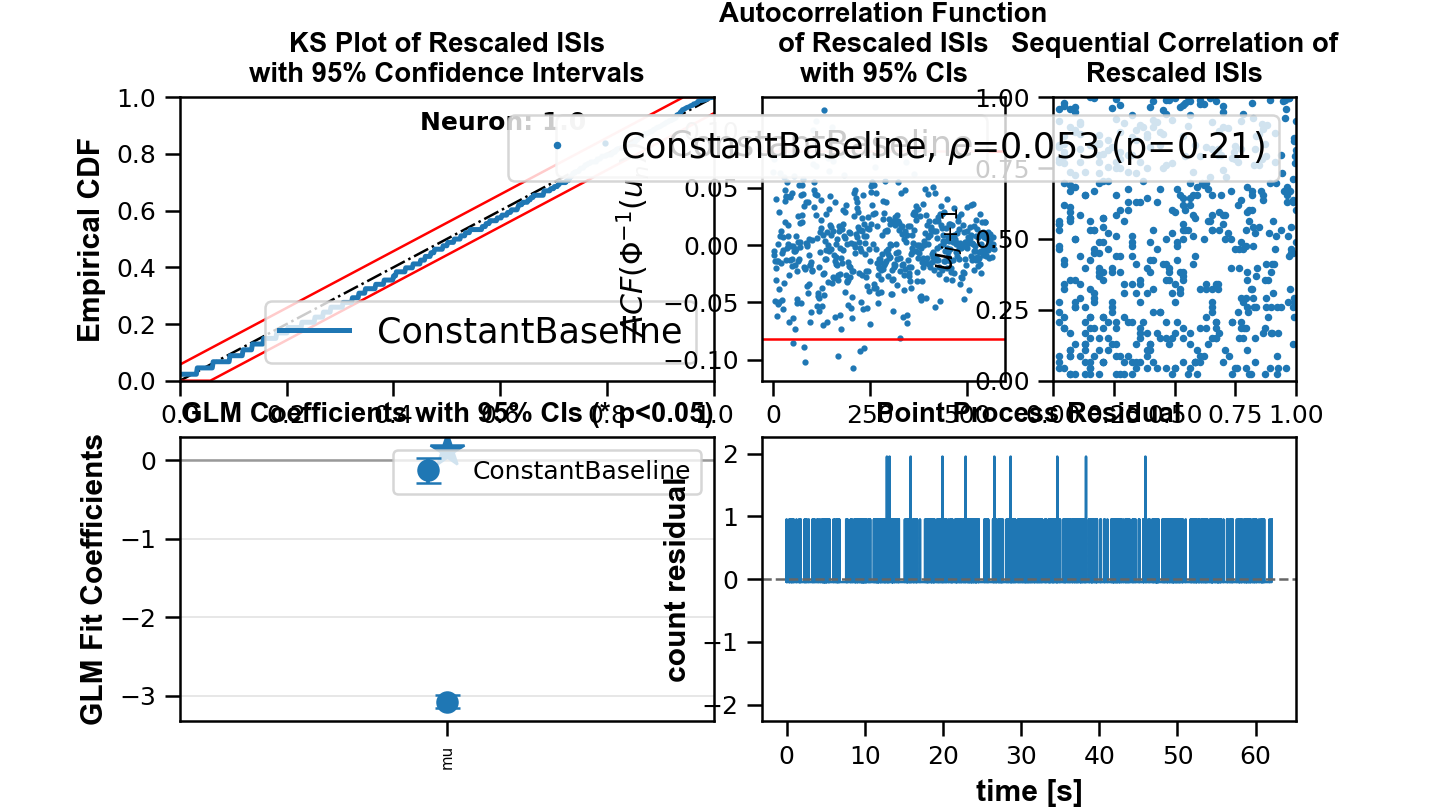

In [3]:
# SECTION 2: Constant Magnesium Concentration - Constant rate poisson
plt.close("all")
const_path = DATA_DIR / "mEPSCs" / "epsc2.txt"
const_data = np.loadtxt(const_path, skiprows=1)
const_spike_times = np.sort(const_data[:, 1] / 1000.0)
const_sample_rate = 200.0
const_time = np.arange(0.0, np.ceil(const_spike_times.max() * const_sample_rate) / const_sample_rate + 1.0 / const_sample_rate, 1.0 / const_sample_rate)
const_baseline = Covariate(const_time, np.ones_like(const_time), "Baseline", "time", "s", "a.u.", ["mu"])
const_trial = Trial(
    nstColl([nspikeTrain(const_spike_times, "1", const_sample_rate, 0.0, float(const_time[-1]), makePlots=-1)]),
    CovColl([const_baseline]),
    Events([], []),
)
const_cfg = ConfigColl([TrialConfig([["Baseline", "mu"]], const_sample_rate, [], [], [], name="ConstantBaseline")])
const_results = Analysis.RunAnalysisForNeuron(const_trial, 1, const_cfg, 0)

fig = __tracker.new_figure("constant-magnesium-results")
const_results.plotResults(handle=fig)
print({"constant_events": int(const_spike_times.size), "AIC": const_results.AIC.tolist()})

In [4]:
# SECTION 3: Varying Magnesium Concentration - Piecewise Constant rate poisson
# When the magnesium concentration of the bath decreased (i.e. magnesium is removed), the rate of mEPSCs begin to increase in frequency. This can be modeled in a many different ways (using the change in Magnesium directly as a model covariate, etc.) Here we approximate the rate as being constant during certain portions of the experiment. These segments can in principle be estimated (using heirarchical Bayesian methods), but here we select them via visual inspection. We compare three models: a constant rate model (from above), a piecewise constant rate model, and a piecewise constant rate model with history.
# load the data;
#
sampleRate = 1000
# Magnesium removed at t=0

/Users/iahncajigas/Library/CloudStorage/Dropbox/Claude/nSTAT-python/nstat/notebook_figures.py:42: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  self._active_fig.tight_layout()


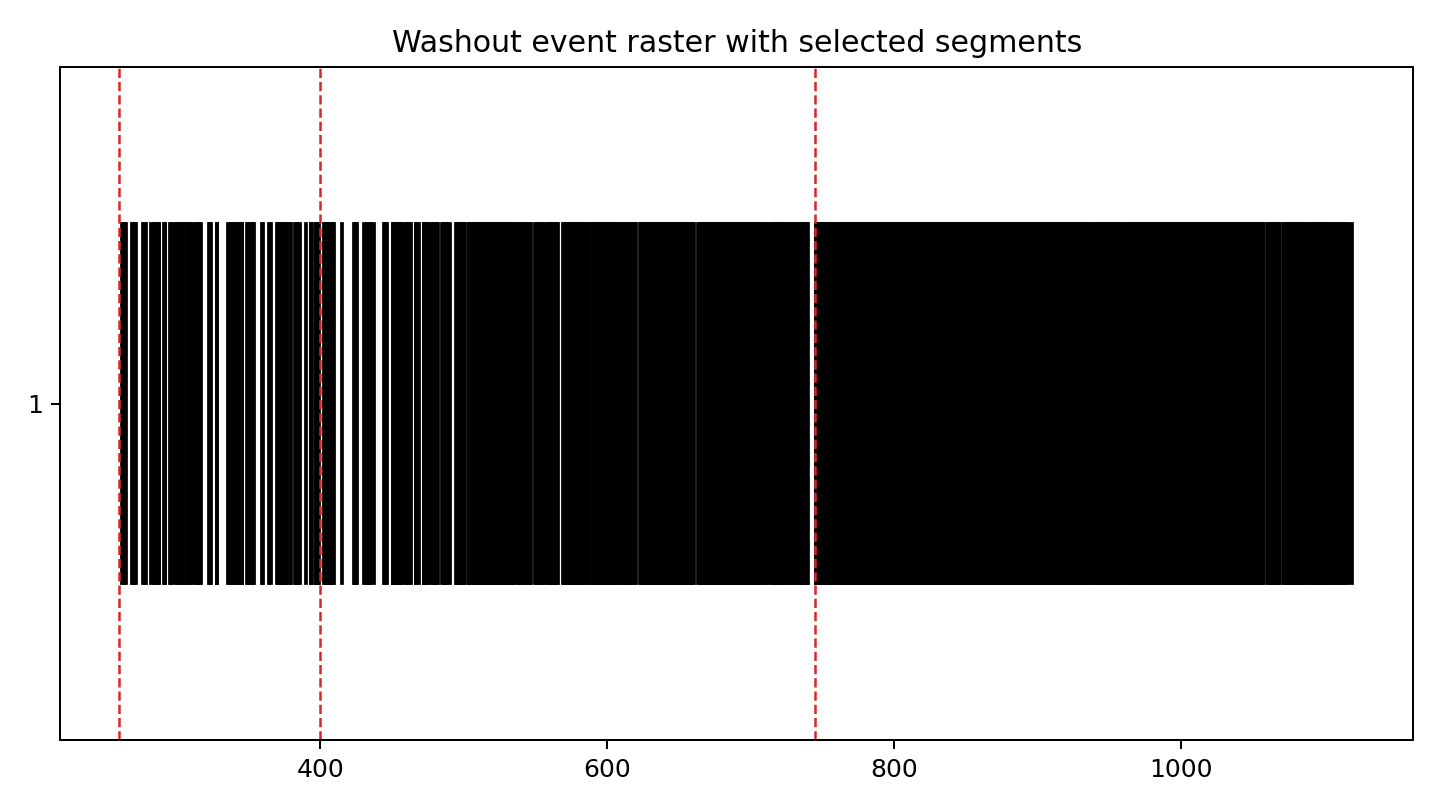

In [5]:
# SECTION 4: Data Visualization
washout1 = np.loadtxt(DATA_DIR / "mEPSCs" / "washout1.txt", skiprows=1)
washout2 = np.loadtxt(DATA_DIR / "mEPSCs" / "washout2.txt", skiprows=1)
analysis_sample_rate = 100.0
washout1_spikes = 260.0 + washout1[:, 1] / 1000.0
washout2_spikes = 745.0 + washout2[:, 1] / 1000.0
washout_spikes = np.sort(np.concatenate([washout1_spikes, washout2_spikes]))

time = np.arange(260.0, np.ceil(washout_spikes.max() * analysis_sample_rate) / analysis_sample_rate + 1.0 / analysis_sample_rate, 1.0 / analysis_sample_rate)
mu_piecewise = np.column_stack([
    (time < 400.0).astype(float),
    ((time >= 400.0) & (time < 745.0)).astype(float),
    (time >= 745.0).astype(float),
])
piecewise_baseline = Covariate(time, mu_piecewise, "Baseline", "time", "s", "a.u.", ["mu_1", "mu_2", "mu_3"])
washout_trial = Trial(
    nstColl([nspikeTrain(washout_spikes, "1", analysis_sample_rate, float(time[0]), float(time[-1]), makePlots=-1)]),
    CovColl([piecewise_baseline]),
    Events([260.0, 745.0], ["washout1", "washout2"]),
)
windowTimes = [0.0, 0.01, 0.03, 0.06, 0.12, 0.20, 0.30]

fig = __tracker.new_figure("washout-raster")
fig.clear()
ax = fig.subplots(1, 1)
washout_trial.nspikeColl.plot(handle=ax)
ax.set_title("Washout event raster with selected segments")
for marker in (260.0, 400.0, 745.0):
    ax.axvline(marker, color="tab:red", linestyle="--", linewidth=1.0)
fig.tight_layout()

In [6]:
# SECTION 5: Define Covariates for the analysis
# 765 onwards third constant rate
# epoch
#
# Create the trial structure
#
# 30ms history in logarithmic spacing (chosen after using
# Analysis.computeHistLagForAll for various window lengths)

In [7]:
# SECTION 6: Define how we want to analyze the data
configs = ConfigColl([
    TrialConfig([["Baseline", "mu_1"]], analysis_sample_rate, [], [], [], name="ConstantBaseline"),
    TrialConfig([["Baseline", "mu_1", "mu_2", "mu_3"]], analysis_sample_rate, [], [], [], name="PiecewiseBaseline"),
    TrialConfig([["Baseline", "mu_1", "mu_2", "mu_3"]], analysis_sample_rate, windowTimes, [], [], name="PiecewiseBaseline+Hist"),
])
results = Analysis.RunAnalysisForNeuron(washout_trial, 1, configs, 0)
summary = FitResSummary([results])
print({"washout_events": int(washout_spikes.size), "config_names": results.configNames})

{'washout_events': 1870, 'config_names': ['ConstantBaseline', 'PiecewiseBaseline', 'PiecewiseBaseline+Hist']}


/Users/iahncajigas/Library/CloudStorage/Dropbox/Claude/nSTAT-python/nstat/fit.py:1174: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  fig.tight_layout()
/Users/iahncajigas/Library/CloudStorage/Dropbox/Claude/nSTAT-python/nstat/notebook_figures.py:42: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  self._active_fig.tight_layout()


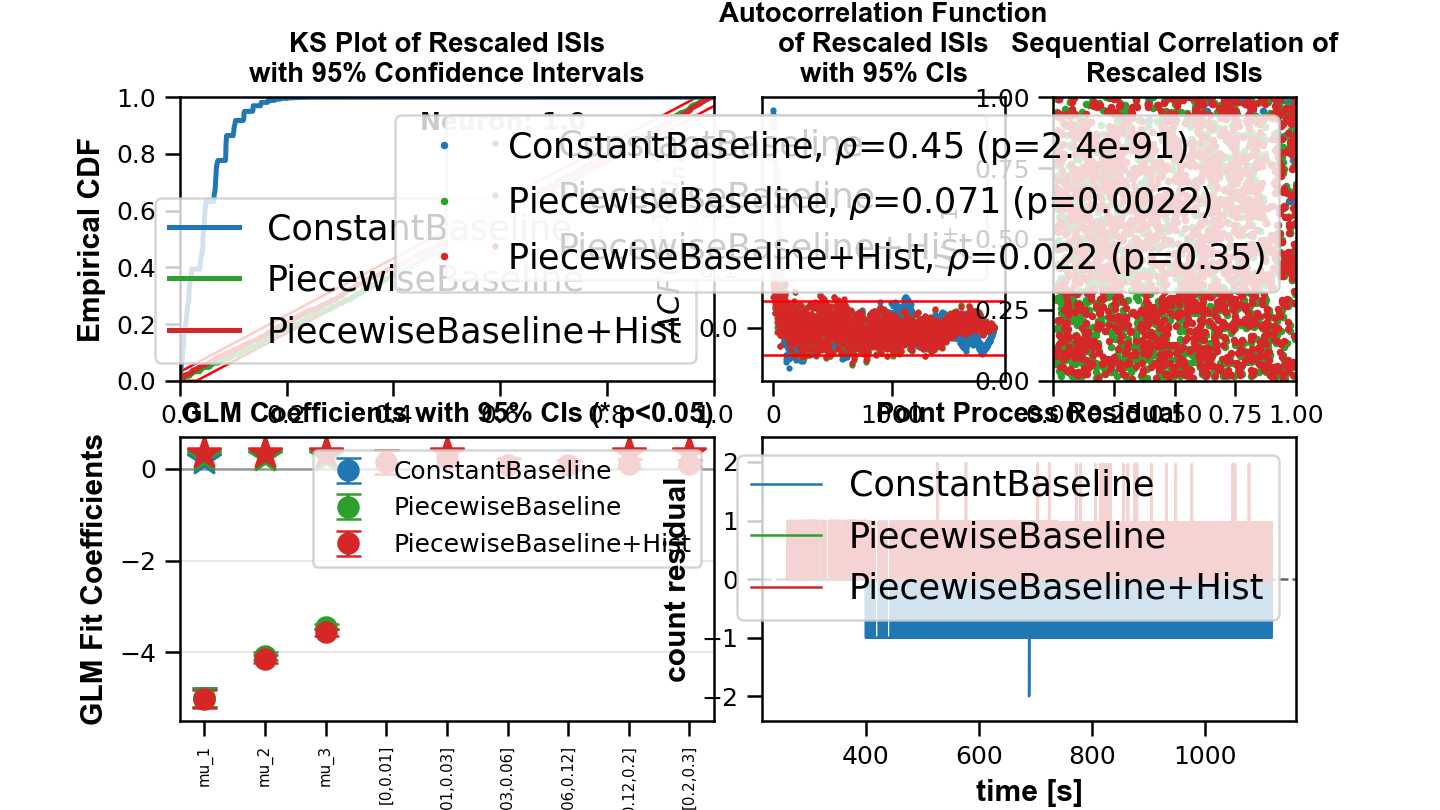

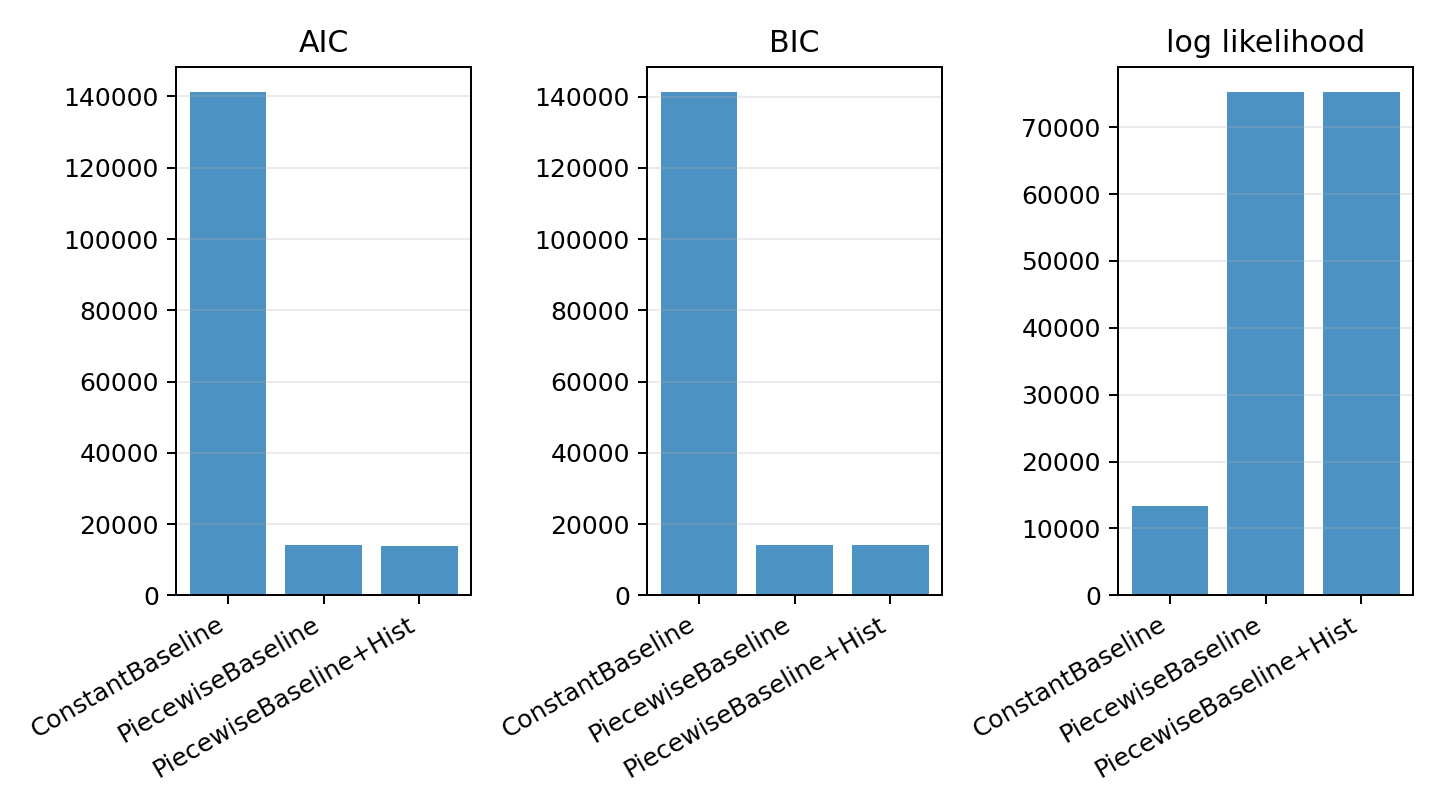

In [8]:
# SECTION 7: Perform Analysis
fig = __tracker.new_figure("washout-analysis-results")
results.plotResults(handle=fig)

fig = __tracker.new_figure("washout-summary")
summary.plotSummary(handle=fig)
__tracker.finalize()

In [9]:
# SECTION 8: Decode Rate using Point Process Filter
# clear lambdaCIF;
# delta = .001;
#
# washout1 = importdata('washout1.txt');
# washout2 = importdata('washout2.txt');
#
# sampleRate  = 1000;
# % Magnesium removed at t=0
# spikeTimes1 = 260+washout1.data(:,2)*1/sampleRate; %in seconds
# spikeTimes2 = sort(washout2.data(:,2))*1/sampleRate + 745;%in seconds
# nst = nspikeTrain([spikeTimes1; spikeTimes2]);
# time = 260:(1/sampleRate):nst.maxTime;
# spikeColl = nstColl(nst);
#
# clear lambdaCIF;
# lambdaCIF = CIF([1],{'mu'},{'mu'},'poisson');
# spikeColl.resample(1/delta);
# dN=spikeColl.dataToMatrix;
# Q=.001;
# Px0=.1; A=1;
# [x_p, Pe_p, x_u, Pe_u] = CIF.PPDecodeFilter(A, Q, Px0, dN',lambdaCIF);
# figure;
# tNew = 260:delta:(length(x_p(1:end-1))*delta+260);
# plot(tNew,exp(x_p)./delta);
#
# %%
# close all;
# N=30000; A=1; B=ones(1,N)./N;
# xfilt = filtfilt(B,A,x_p);
# figure;
# plot(tNew,x_p,'-.b');
# hold on; plot(tNew,xfilt,'k','Linewidth',3);
# %%
# close all;
# figure;
# index = find(tNew<280,1,'last');
# subplot(2,1,1);
# plot(tNew(index:end),x_p(index:end),'-.b'); hold on;
# plot(tNew(index:end),xfilt(index:end),'k','Linewidth',3);
# xlabel('time [s]');
# ylabel('\mu');
# axis tight;
# v=axis;
# axis([v(1) v(2) -9 -5]);
#
# subplot(2,1,2);
# plot(tNew(index:end),exp(x_p(index:end))./delta,'-.b'); hold on;
# plot(tNew(index:end),exp(xfilt(index:end))./delta,'k','Linewidth',3);
# axis tight;
# v=axis;
# axis([v(1) v(2) 0 5]);
# xlabel('time [s]');
# ylabel('\lambda(t) [Hz]');
__tracker.finalize()